# imports

In [8]:
import matplotlib.pyplot as plt
import scipy
import numpy as np
from pyquaternion import Quaternion
from scipy.interpolate import RBFInterpolator


import sys 
sys.path.append("../General_Functions/")

from Flow_functions import *
from Geometric_functions import *

In [9]:
# Calculate simplified braitenberg strategy

def Braitenberg_angular_speed(n, x, e, gradient):
    """Finite difference implementation of Braitenberg angularspeed"""
    AntennaeLength = 1e-2
    x1 = x + AntennaeLength * n
    x2 = x - AntennaeLength * n

    # Flow measured in the cope reference system
    gradient1 = np.dot(n, gradient(e, x1))
    gradient2 = np.dot(n, gradient(e, x2))
    S1 = np.linalg.norm(gradient1)
    S2 = np.linalg.norm(gradient2)
    return (S1 - S2) / ((S1 + S2) * 2 * AntennaeLength)

# Parameters

In [20]:
grad = GradientStokeslet  # Note: it should work with a strain or another flow
grad_name = "GradientStokeslet" # For saving porpouses
e = np.array([1, 0, 0])  # orientation of the flow
Nagent = 10  # number of agent positions (in the quarter circle of radius 1)
Npoints = 60 # Resolution of space sampling
Duration = 255 # Max number of timesteps in simulations
dt = .1 # timestep lenght
twist = 0.01 # Rotation around swimming direction t
x = np.linspace(0.1, 5.5, Npoints) # x axis position of the agent
z = np.linspace(0.1, 5.5, Npoints) # z axis position of the agent
X, Z = np.meshgrid(x, z) # Create 2D grid

T_mean = np.zeros((Npoints, Npoints, 3))
Perf = np.zeros((Npoints, Npoints))

In [21]:
# Numerically integrate angular dynamics

def Evolution(n, b, t, AgentPosition, FlowGradient, e, dt, twist):
    
    # Angular speed around axis b
    AngularSpeed = Braitenberg_angular_speed(n, AgentPosition, e, FlowGradient)
    
    Rotation_b = Quaternion(axis = b, angle = AngularSpeed*dt) 
    new_n = Rotation_b.rotate(n)
    new_b = Rotation_b.rotate(b)
    new_t = Rotation_b.rotate(t)
    
    # Twist around axis t 
    Rotation_t = Quaternion(axis= new_t, angle = twist * dt)
    new_n2 = Rotation_t.rotate(new_n)
    new_b2 = Rotation_t.rotate(new_b)
    new_t2 = Rotation_t.rotate(new_t)
    
    new_n2 /= np.linalg.norm(new_n2)
    new_b2 /= np.linalg.norm(new_b2)
    new_t2 /= np.linalg.norm(new_t2)
    
    return new_n2, new_b2, new_t2

In [22]:
# initialize 
t0_Braitenberg, t1_Braitenberg, t2_Braitenberg = np.zeros((Npoints, Npoints, Nagent)), np.zeros((Npoints, Npoints, Nagent)), np.zeros((Npoints, Npoints, Nagent))
DotProduct_Braitenberg = np.zeros((Npoints, Npoints, Nagent))


for k in range(Npoints):
    for i in range(Npoints):
        AgentPosition =  np.array([z[k], x[i], 0.])
        OptimalDirection = -AgentPosition/np.linalg.norm(AgentPosition)
    
        for trials_i in range(Nagent):
            alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
            RotationMatrix = Rotation(alpha, np.abs(beta), gamma)

            n_Braitenberg = np.dot(RotationMatrix,[0, 1, 0])
            b_Braitenberg = np.dot(RotationMatrix,[0, 0, 1])
            t_Braitenberg = np.dot(RotationMatrix,[1, 0, 0])

            for time in range(Duration):
                n_Braitenberg, b_Braitenberg, t_Braitenberg = Evolution(n_Braitenberg, b_Braitenberg, t_Braitenberg,  AgentPosition, grad, e, dt, twist)

            t0_Braitenberg[k, i, trials_i], t1_Braitenberg[k, i, trials_i], t2_Braitenberg[k, i, trials_i] = t_Braitenberg
            DotProduct_Braitenberg[k, i, trials_i] = np.dot(t_Braitenberg, OptimalDirection)


# Plot

In [23]:
DotProduct_Braitenberg = scipy.ndimage.gaussian_filter(np.mean(DotProduct_Braitenberg, axis = 2), sigma=[2,3], mode='constant')

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


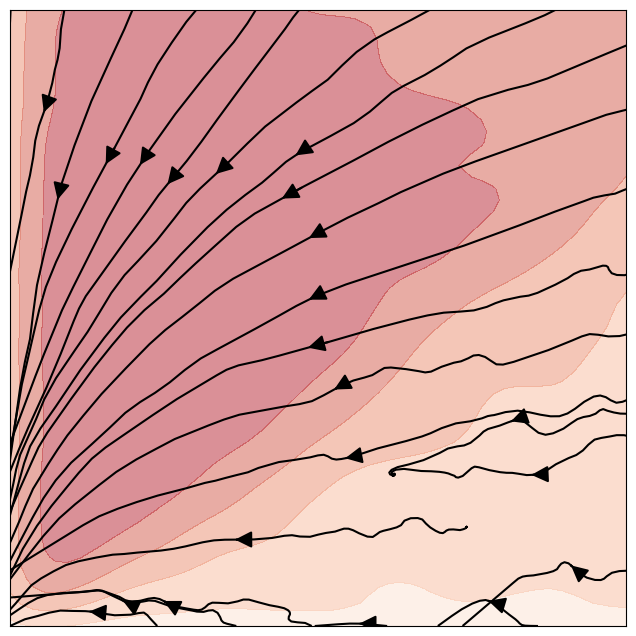

In [24]:
# Plot parameters
CMAP = 'RdBu_r' #'spring'
STREAMCOLOR = 'black'

fig1, axs = plt.subplots(nrows=1, ncols=1, figsize=(8,8), sharex='col', sharey='row')
ax1 = axs
X, Z = np.meshgrid(x, z, indexing='xy')

# Add data to image grid
levels = np.linspace(-1, 1.00001, 14)
# Smooth results

im = ax1.contourf(X, Z, DotProduct_Braitenberg, cmap = CMAP, levels = levels, vmin= -1, vmax = 1, alpha = 0.5)
ax1.streamplot(X, Z, np.mean(t1_Braitenberg, axis=2), np.mean(t0_Braitenberg, axis=2), color=STREAMCOLOR, density = .35,  arrowsize = 2.5, broken_streamlines=False)
#PlotCircles(ax1, .5)
ax1.set_xlim([.1, 5])
ax1.set_ylim([.1, 5])
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_aspect("equal")


#plt.colorbar(im, ax = axs, ticks = np.arange(-1, 1.1, 0.5), location= 'bottom')
# Uncomment to save
plt.savefig("Plots/Brait_simulation_"+grad_name+".eps", format = 'eps', bbox_inches='tight')
plt.savefig("Plots/Brait_simulation_"+grad_name+".pdf", bbox_inches='tight')
plt.show()